# Thai licence-plate reader — offline, reading the letters one by one

| part | example | how it is read |
|---|---|---|
| **letters** | 5กข | cut into single glyphs **[5] [ก] [ข]**, each read **on its own**, then combined and checked against the plate format |
| **number** | 2662 | EasyOCR, digits only |
| **province** | กรุงเทพมหานคร | EasyOCR, then matched to the official list of 77 provinces + เบตง |

Letter engines (all free and local): **EasyOCR** per letter, a small **CNN** trained on free fonts,
**Tesseract**, **PaddleOCR** (optional) — or an average of several. The default averages EasyOCR and the CNN and flags the plate
for review when they disagree.

Files in this folder:

* `thai_plate_reader.py` – the reader (import it or run it from the command line)
* `thai_letter_cnn.pt` – weights of the letter CNN (0.5 MB); `train_letter_cnn.py` – how it was trained / retrain it
* `sample_plate.png` (ฒก 8534), `sample_plate2.png` (5กข 2662, graphic plate) – example photos
* `requirements.txt` – dependencies

## 0. Install (once)
Uncomment and run. EasyOCR downloads its Thai model (`thai.pth`, ~215 MB) into `~/.EasyOCR/model` the first time.
Tesseract and PaddleOCR are optional extras (see `requirements.txt`).

In [1]:
# %pip install -r requirements.txt

## 1. Load the reader — once
Loading takes a few seconds. In an API server create **one** `ThaiPlateReader` at start-up and reuse it.

In [2]:
import json
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import thai_plate_reader as tpr
from thai_plate_reader import (
    DIGITS, NUMBER_RE, PlateNotFound, ThaiPlateReader, combine_letters, debug_sheet,
    field_crop, glyph_crop, imread, imwrite, letter_allowed_sets, normalise_plate,
    plate_candidates, segment_plate, warp_plate,
)

t = time.perf_counter()
reader = ThaiPlateReader(gpu=False)   # letters_engine="auto" -> EasyOCR + CNN, one letter at a time
print(f"model loaded in {time.perf_counter() - t:.1f} s; letters engine: {reader.letters_engine.name}")

model loaded in 2.3 s; letters engine: easyocr+cnn


## 2. Read both example plates

In [3]:
rows = []
for path in ["sample_plate.png", "sample_plate2.png"]:
    r = reader.read(path)
    rows.append({"image": path, "plate": r["plate"], "province": r["province"],
                 "letters read by": r["letters_detail"]["mode"],
                 "each engine said": r["letters_detail"]["by_engine"],
                 "letters conf": r["confidence"]["letters"], "needs_review": r["needs_review"],
                 "time (ms)": r["timing_ms"]["total"]})
pd.DataFrame(rows)

,image,plate,province,letters read by,each engine said,letters conf,needs_review,time (ms)
0,sample_plate.png,ฒก 8534,กรุงเทพมหานคร,per-letter (easyocr+cnn),"{'easyocr': 'ฒก', 'cnn': 'ฒก'}",0.462,True,654
1,sample_plate2.png,5กข 2662,กรุงเทพมหานคร,per-letter (easyocr+cnn),"{'easyocr': '5กข', 'cnn': '5กข'}",0.951,False,710


The full result for the graphic plate — one key per line (this is what an API would return as JSON):

In [4]:
result = reader.read("sample_plate2.png")
for key, value in result.items():
    print(f"{key:15s} {json.dumps(value, ensure_ascii=False)}")

plate           "5กข 2662"
letters         "5กข"
number          "2662"
province        "กรุงเทพมหานคร"
confidence      {"letters": 0.951, "number": 1.0, "province": 1.0, "province_vs_raw_ocr": 0.923}
alternatives    {"letters": [["5กข", 0.951], ["5ทข", 0.007], ["3กข", 0.003], ["5กบ", 0.003], ["5กช", 0.002]], "number": [["2662", 1.0]], "province": [["กรุงเทพมหานคร", 1.0]]}
letters_detail  {"mode": "per-letter (easyocr+cnn)", "per_letter_top3": [[["5", 0.994], ["3", 0.003], ["6", 0.001]], [["ก", 0.97], ["ท", 0.007], ["ภ", 0.002]], [["ข", 0.986], ["บ", 0.003], ["ช", 0.002]]], "by_engine": {"easyocr": "5กข", "cnn": "5กข"}}
raw_ocr         {"letters": "5กข", "number": "2662", "province": "กรุงเทพมทานคร"}
checks          {"letters_format": true, "number_format": true, "letters_glyph_count": true, "number_glyph_count": true, "letter_engines_agree": true}
needs_review    false
timing_ms       {"segment": 33, "letters": 290, "number_province": 392, "total": 715}


## 3. Step by step on the graphic plate

### 3.1 Find the plate and straighten it
The plate face is the largest light, rectangular region (about 1.5–4 : 1); it is warped flat to 220 px high.
(`read()` tries several candidates and keeps the first with a valid plate layout; here we just take the first.)

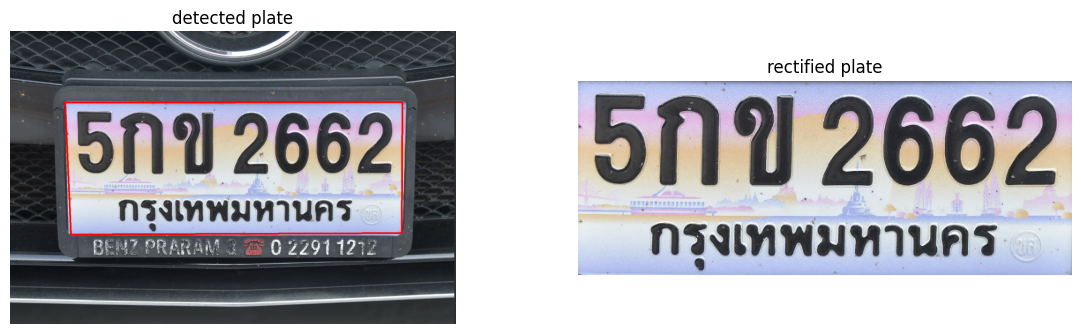

In [5]:
img = imread("sample_plate2.png")
quad = plate_candidates(img)[0]
plate = warp_plate(img, quad)

vis = img.copy()
cv2.polylines(vis, [quad.astype(int)], True, (0, 0, 255), 4)
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
ax[0].imshow(vis[..., ::-1]); ax[0].set_title("detected plate")
ax[1].imshow(plate[..., ::-1]); ax[1].set_title("rectified plate")
for a in ax:
    a.axis("off")
plt.show()

### 3.2 Remove the background picture and find the ink
The colour channel with the best text/background contrast is chosen, lighting is flattened, then the text is thresholded —
the skyline picture on this plate disappears from the ink mask.

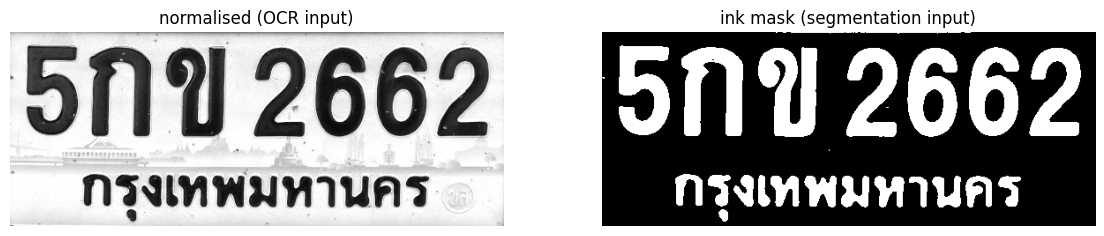

In [6]:
norm, ink = normalise_plate(plate)
fig, ax = plt.subplots(1, 2, figsize=(14, 3))
ax[0].imshow(norm, cmap="gray"); ax[0].set_title("normalised (OCR input)")
ax[1].imshow(ink, cmap="gray"); ax[1].set_title("ink mask (segmentation input)")
for a in ax:
    a.axis("off")
plt.show()

### 3.3 Cut the fields — and cut the letters into single glyphs
* tall glyphs form the top line; the **widest gap** splits letters from the number
* each letter glyph is cropped **on its own**, with the ink of its neighbours erased
* smaller glyphs below form the province line (the round emblem is dropped)

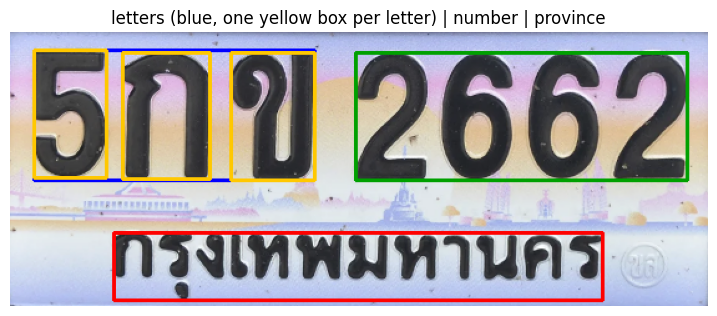

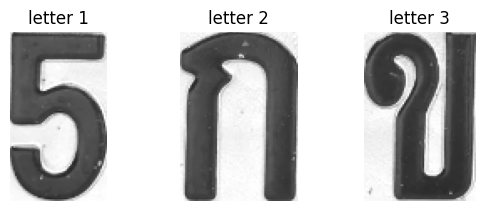

In [7]:
seg = segment_plate(ink)

colours = {"letters": (255, 0, 0), "number": (0, 160, 0), "province": (0, 0, 255)}   # BGR
boxed = plate.copy()
for name, col in colours.items():
    x0, y0, x1, y1 = seg[name].as_tuple()
    cv2.rectangle(boxed, (x0, y0), (x1, y1), col, 2)
for g in seg["letter_glyphs"]:                                   # each letter in yellow
    cv2.rectangle(boxed, (g.x0, g.y0), (g.x1, g.y1), (0, 200, 255), 2)

glyphs = [glyph_crop(norm, ink, seg["labels"], g) for g in seg["letter_glyphs"]]
crops = {name: field_crop(norm, ink, seg["labels"], seg[name]) for name in ("number", "province")}

plt.figure(figsize=(9, 4))
plt.imshow(boxed[..., ::-1]); plt.title("letters (blue, one yellow box per letter) | number | province"); plt.axis("off")
plt.show()

fig, ax = plt.subplots(1, len(glyphs), figsize=(2.2 * len(glyphs), 2.2))
for i, (a, g) in enumerate(zip(np.atleast_1d(ax), glyphs)):
    a.imshow(g, cmap="gray", vmin=0, vmax=255); a.set_title(f"letter {i + 1}"); a.axis("off")
plt.show()

### 3.4 Read each letter on its own, then combine
Every engine returns, **for each glyph separately**, a probability for every character allowed at that position
(from the plate format: a 3-glyph group is *digit + consonant + consonant*). `combine_letters` then joins the per-letter
results into the string and ranks alternatives.

In [8]:
allowed = letter_allowed_sets(len(glyphs))
engines = {"easyocr": tpr.EasyOCRLetters(reader), "cnn": tpr.CNNLetters()}
# optional installs (see requirements.txt): tesseract needs the tesseract program + Thai data,
# paddle needs paddlepaddle (its Thai model, 8 MB, downloads on first use)
for name in ("tesseract", "paddle"):
    try:
        engines[name] = reader.make_letters_engine(name)
        engines[name].predict(glyphs[:1], allowed[:1])
    except Exception as e:
        engines.pop(name, None)
        print(f"{name} not available:", type(e).__name__)

rows = []
for name, engine in engines.items():
    dists = engine.predict(glyphs, allowed)
    for i, (p, al) in enumerate(zip(dists, allowed)):
        top = np.argsort(-p)[:3]
        rows.append({"engine": name, "letter": i + 1,
                     "top 3 (probability)": "  ".join(f"{al[j]} {p[j]:.2f}" for j in top)})
    rows.append({"engine": name, "letter": "combined",
                 "top 3 (probability)": combine_letters(dists, allowed)["text"]})
pd.DataFrame(rows)

,engine,letter,top 3 (probability)
0,easyocr,1,5 1.00 6 0.00 3 0.00
1,easyocr,2,ก 1.00 ท 0.00 ภ 0.00
2,easyocr,3,ข 0.99 บ 0.01 ช 0.00
3,easyocr,combined,5กข
4,cnn,1,5 0.99 3 0.00 6 0.00
5,cnn,2,ก 0.96 ท 0.01 ภ 0.00
6,cnn,3,ข 0.98 ช 0.00 ญ 0.00
7,cnn,combined,5กข
8,tesseract,1,5 0.96 1 0.00 2 0.00
9,tesseract,2,ก 0.94 บ 0.00 ป 0.00


### 3.5 Number and province (EasyOCR)
The province is chosen by scoring every official province name with the model's CTC likelihood, so small OCR slips are corrected.

In [9]:
number = reader.read_code(crops["number"], DIGITS, NUMBER_RE)
province = reader.read_province(crops["province"])
pd.DataFrame([{"field": "number", "EasyOCR raw text": number["raw"], "final": number["text"]},
              {"field": "province", "EasyOCR raw text": province["raw"], "final": province["text"]}])

,field,EasyOCR raw text,final
0,number,2662,2662
1,province,กรุงเทพมทานคร,กรุงเทพมหานคร


## 4. Letter engines compared
Same two photos, letters only. `group` is the old behaviour (EasyOCR reads the whole letters crop at once) —
it misreads ฒ as ผ; reading one letter at a time fixes it. PaddleOCR on its own reads ฒ as 7; averaged with
EasyOCR and the CNN (`easyocr+cnn+paddle`) it is outvoted.

In [10]:
specs = ["group", "easyocr", "cnn", "easyocr+cnn"] + [s for s in ("tesseract", "paddle") if s in engines]
if "paddle" in engines:
    specs.append("easyocr+cnn+paddle")
rows = []
for spec in specs:
    reader.letters_engine = reader.make_letters_engine(spec)
    row = {"letters engine": spec}
    for path, truth in (("sample_plate.png", "ฒก"), ("sample_plate2.png", "5กข")):
        res = reader.read(path)
        row[path] = f"{res['letters']} {'✓' if res['letters'] == truth else '✗'}"
        row[f"{path} letters ms"] = res["timing_ms"]["letters"]
    rows.append(row)
reader.letters_engine = reader.make_letters_engine("easyocr+cnn")   # back to the default
pd.DataFrame(rows)

,letters engine,sample_plate.png,sample_plate.png letters ms,sample_plate2.png,sample_plate2.png letters ms
0,group,ผก ✗,68,5กข ✓,69
1,easyocr,ฒก ✓,221,5กข ✓,288
2,cnn,ฒก ✓,4,5กข ✓,4
3,easyocr+cnn,ฒก ✓,232,5กข ✓,296
4,tesseract,ฒก ✓,181,5กข ✓,203
5,paddle,7ก ✗,131,5กข ✓,195
6,easyocr+cnn+paddle,ฒก ✓,353,5กข ✓,493


## 5. Debug sheet
Detected plate, ink mask, the boxes, then the exact inputs: each letter glyph, the number and the province.
(Same as `python thai_plate_reader.py photo.jpg --debug debug.png`.)

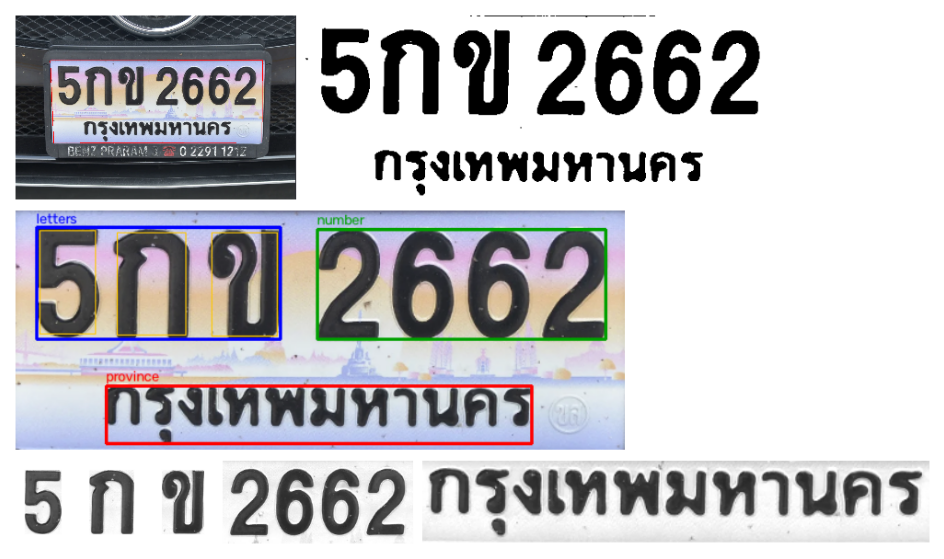

In [11]:
res = reader.read("sample_plate2.png", return_debug=True)
plt.figure(figsize=(12, 7))
plt.imshow(debug_sheet(res.pop("_debug"))[..., ::-1]); plt.axis("off")
plt.show()

## 6. Robustness check — both photos under harder conditions

In [12]:
def rotate(im, deg):
    h, w = im.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), deg, 1.0)
    return cv2.warpAffine(im, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

def variants(im):
    return {
        "original": im,
        "rotated -8 deg": rotate(im, -8),
        "blurred": cv2.GaussianBlur(im, (0, 0), 2),
        "1/3 resolution": cv2.resize(im, None, fx=1 / 3, fy=1 / 3, interpolation=cv2.INTER_AREA),
        "shadow": np.clip(im * np.linspace(0.45, 1.1, im.shape[1])[None, :, None], 0, 255).astype(np.uint8),
        "JPEG quality 30": cv2.imdecode(cv2.imencode(".jpg", im, [cv2.IMWRITE_JPEG_QUALITY, 30])[1], cv2.IMREAD_COLOR),
    }

rows = []
for path in ["sample_plate.png", "sample_plate2.png"]:
    for name, im in variants(imread(path)).items():
        r = reader.read(im)
        rows.append({"photo": path, "variant": name, "plate": r["plate"], "province": r["province"],
                     "engines": r["letters_detail"]["by_engine"], "needs_review": r["needs_review"],
                     "time (ms)": r["timing_ms"]["total"]})
pd.DataFrame(rows)

,photo,variant,plate,province,engines,needs_review,time (ms)
0,sample_plate.png,original,ฒก 8534,กรุงเทพมหานคร,"{'easyocr': 'ฒก', 'cnn': 'ฒก'}",True,588
1,sample_plate.png,rotated -8 deg,ฒก 8534,กรุงเทพมหานคร,"{'easyocr': 'ฒก', 'cnn': 'ฒก'}",True,605
2,sample_plate.png,blurred,ฒก 8534,กรุงเทพมหานคร,"{'easyocr': 'ฒก', 'cnn': 'ฒก'}",True,559
3,sample_plate.png,1/3 resolution,ฒก 8534,กรุงเทพมหานคร,"{'easyocr': 'ฒก', 'cnn': 'ฒก'}",True,594
4,sample_plate.png,shadow,ฒก 8534,กรุงเทพมหานคร,"{'easyocr': 'ฒก', 'cnn': 'ฒก'}",True,573
5,sample_plate.png,JPEG quality 30,ฒก 8534,กรุงเทพมหานคร,"{'easyocr': 'ฒก', 'cnn': 'ฒก'}",True,604
6,sample_plate2.png,original,5กข 2662,กรุงเทพมหานคร,"{'easyocr': '5กข', 'cnn': '5กข'}",False,642
7,sample_plate2.png,rotated -8 deg,5กข 2662,กรุงเทพมหานคร,"{'easyocr': '5กข', 'cnn': '5กข'}",False,670
8,sample_plate2.png,blurred,5กข 2662,กรุงเทพมหานคร,"{'easyocr': '5กข', 'cnn': '5กข'}",False,649
9,sample_plate2.png,1/3 resolution,5กข 2662,กรุงเทพมหานคร,"{'easyocr': '5กข', 'cnn': '5กข'}",False,633


## 7. Your own photos — and teaching the CNN your plates
Put photos in `images/` next to this notebook (the two samples are used if the folder does not exist).
Every letter glyph is saved to `glyphs/<character>/...png` using the reader's answer. Move any wrongly-filed glyph into the right
folder, then retrain the CNN with your real glyphs added:

```
python train_letter_cnn.py --download-fonts fonts/                       # once
python train_letter_cnn.py --fonts fonts/ --real glyphs/ --out thai_letter_cnn.pt
```

In [13]:
IMAGE_DIR, GLYPH_DIR = Path("images"), Path("glyphs")
paths = sorted(p for p in IMAGE_DIR.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}) \
    if IMAGE_DIR.exists() else [Path("sample_plate.png"), Path("sample_plate2.png")]

rows = []
for p in paths:
    try:
        r = reader.read(str(p), return_debug=True)
    except PlateNotFound as e:
        rows.append({"image": p.name, "error": str(e)})
        continue
    dbg = r.pop("_debug")
    for i, (ch, g) in enumerate(zip(r["letters"], dbg["glyphs"])):
        (GLYPH_DIR / ch).mkdir(parents=True, exist_ok=True)
        imwrite(GLYPH_DIR / ch / f"{p.stem}_{i}.png", g)
    rows.append({"image": p.name, "plate": r["plate"], "province": r["province"],
                 "needs_review": r["needs_review"], "time (ms)": r["timing_ms"]["total"]})
print(f"{len(paths)} image(s); letter glyphs saved under {GLYPH_DIR}/<character>/")
pd.DataFrame(rows)

2 image(s); letter glyphs saved under glyphs/<character>/


,image,plate,province,needs_review,time (ms)
0,sample_plate.png,ฒก 8534,กรุงเทพมหานคร,True,585
1,sample_plate2.png,5กข 2662,กรุงเทพมหานคร,False,680


## 8. Notes
* **Speed** – about 1 s per plate on a 2-core CPU with the default EasyOCR + CNN letters (`letters_engine="cnn"` alone saves
  ~0.4 s). Load the reader once; `gpu=True` is much faster.
* **Engines** – EasyOCR, the CNN and Tesseract are Apache-2.0 / your own model; the CNN was trained only on renders of free
  OFL fonts (Google Fonts) — no plate photos. PaddleOCR's Thai model (Apache-2.0, `letters_engine="paddle"`) is optional and
  not in the default: on its own it misreads ฒ as 7 on `sample_plate.png` (see section 4).
* **Review flag** – `needs_review` is set when the letter engines disagree, a confidence is low, or a format check fails.
* **Offline server** – copy `thai.pth` and use `ThaiPlateReader(model_storage_directory="models/", download_enabled=False)`.
* **Not covered** – motorcycle plates (3-line layout), wide CCTV frames (crop the plate with a detector first).
* **Command line** – `python thai_plate_reader.py photo.jpg --letters easyocr+cnn --debug debug.png --json`